In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="pastel")

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
plt.rcParams['figure.figsize'] = (12, 6)


plt.rcParams['font.family'] = 'DejaVu Sans'  
plt.rcParams['axes.unicode_minus'] = False  


In [ ]:
df = pd.read_csv("../../data/processed/clean_dataset.csv")
df_vi = df.copy()

In [3]:
display(df_vi.head(5))

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,29/07/2023 13:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,13,7,7
1,13/08/2023 0:11,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,2,0,1,8
2,09/12/2021 10:30,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,10,5,12
3,09/08/2023 19:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5,0,0,5,0,0,19,4,8
4,19/08/2023 14:55,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0,0,0,0,0,3,14,7,8


In [4]:
print("\n=== DESCRIBE ===")
display(df_vi.describe())


=== DESCRIBE ===


,intersection_related_i,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000,209275.000000
mean,0.952307,2.063299,0.382707,0.001859,0.038103,0.221226,0.121520,2.244019,13.372897,4.144045,6.771798
std,0.213117,0.396030,0.799720,0.047505,0.233971,0.614939,0.450884,1.241159,5.604019,1.966880,3.427626
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,1.000000,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


In [5]:
injury_map = {
    "FATAL": "Tử vong",
    "INCAPACITATING INJURY": "Thương nặng",
    "NONINCAPACITATING INJURY": "Thương nhẹ",
    "REPORTED, NOT EVIDENT": "Có báo cáo nhưng không rõ",
    "NO INDICATION OF INJURY": "Không bị thương"
}

weather_map = {
    "CLEAR": "Trời quang",
    "RAIN": "Mưa",
    "SNOW": "Tuyết",
    "FOG/SMOKE/HAZE": "Sương mù",
    "CLOUDY/OVERCAST": "Nhiều mây",
    "FREEZING RAIN/DRIZZLE": "Mưa đóng băng",
    "SLEET/HAIL": "Mưa đá",
    "BLOWING SNOW": "Tuyết thổi",
    "BLOWING SAND, SOIL, DIRT": "Gió cát/bụi",
    "SEVERE CROSS WIND GATE": "Gió ngang mạnh",
    "OTHER": "Khác",
    "UNKNOWN": "Không rõ"
}
lighting_map = {
    "DAYLIGHT": "Ban ngày",
    "DARKNESS": "Ban đêm",
    "DARKNESS, LIGHTED ROAD": "Ban đêm (có đèn)",
    "DUSK": "Hoàng hôn",
    "DAWN": "Bình minh",
    "UNKNOWN": "Không rõ"
}
road_map = {
    "DRY": "Khô",
    "WET": "Ướt",
    "SNOW OR SLUSH": "Tuyết/bùn",
    "ICE": "Băng",
    "UNKNOWN": "Không rõ",
    "SAND, MUD, DIRT": "Cát, bùn, bụi",
    "OTHER": "Khác"
}
crash_map = {
    "REAR END": "Va chạm phía sau",
    "ANGLE": "Va chạm góc",
    "HEAD ON": "Đâm trực diện",
    "SIDESWIPE SAME DIRECTION": "Quệt cùng chiều",
    "SIDESWIPE OPPOSITE DIRECTION": "Quệt ngược chiều",
    "PEDESTRIAN": "Người đi bộ",
    "PEDALCYCLIST": "Xe đạp",
    "PARKED MOTOR VEHICLE": "Xe đỗ",
    "FIXED OBJECT": "Vật cố định",
    "TURNING": "Va chạm khi rẽ",
    "ANIMAL": "Động vật",
    "OTHER OBJECT": "Vật khác"
}
cause_map = {
    "FAILING TO YIELD RIGHT-OF-WAY": "Không nhường đường",
    "FOLLOWING TOO CLOSELY": "Bám đuôi",
    "IMPROPER OVERTAKING/PASSING": "Vượt sai quy định",
    "DISREGARDING TRAFFIC SIGNALS": "Vượt đèn tín hiệu",
    "SPEEDING": "Chạy quá tốc độ",
    "DRIVING SKILLS/KNOWLEDGE/EXPERIENCE": "Thiếu kỹ năng lái xe",
    "WEATHER": "Thời tiết",
    "ROAD ENGINEERING/SURFACE/MARKING DEFECTS": "Lỗi đường sá",
    "OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER": "Lái xe ẩu",
    "UNABLE TO DETERMINE": "Không xác định",
    "PHYSICAL CONDITION OF DRIVER": "Tình trạng sức khỏe",
    "VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)": "Tầm nhìn bị che khuất",
    "UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)": "Rượu/bia, chất kích thích",
    "DISTRACTION - FROM INSIDE VEHICLE": "Mất tập trung (trong xe)",
    "DISTRACTION - FROM OUTSIDE VEHICLE": "Mất tập trung (ngoài xe)",
    "EQUIPMENT - VEHICLE CONDITION": "Lỗi phương tiện",
    "IMPROPER BACKING": "Lùi xe sai",
    "IMPROPER TURNING/NO SIGNAL": "Rẽ không đúng / không xi nhan",
    "HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)": "Có uống rượu",
    "PASSING STOPPED SCHOOL BUS": "Vượt xe buýt trường học",
    "EXCEEDING AUTHORIZED SPEED LIMIT": "Vượt tốc độ cho phép",
    "NOT APPLICABLE": "Không áp dụng",
    "OTHER": "Khác"
}
trafficway_map = {
    "ALLEY": "Hẻm",
    "CENTER TURN LANE": "Làn rẽ giữa",
    "DIVIDED - W/MEDIAN (NOT RAISED)": "Đường phân cách (không dải cứng)",
    "DIVIDED - W/MEDIAN BARRIER": "Đường có dải phân cách cứng",
    "DRIVEWAY": "Lối ra vào",
    "FIVE POINT, OR MORE": "Giao lộ ≥ 5 hướng",
    "FOUR WAY": "Ngã tư",
    "L-INTERSECTION": "Ngã ba chữ L",
    "NOT DIVIDED": "Đường không phân cách",
    "ONE-WAY": "Đường một chiều",
    "OTHER": "Khác",
    "PARKING LOT": "Bãi đỗ xe",
    "RAMP": "Đường lên/xuống (ramp)",
    "ROUNDABOUT": "Vòng xoay",
    "T-INTERSECTION": "Ngã ba chữ T",
    "TRAFFIC ROUTE": "Tuyến giao thông chính",
    "UNKNOWN": "Không rõ",
    "Y-INTERSECTION": "Ngã ba chữ Y"
}
traffic_control_map = {
   "BICYCLE CROSSING SIGN": "Biển báo xe đạp cắt ngang",
    "DELINEATORS": "Cọc tiêu/Thiết bị dẫn hướng",
    "FLASHING CONTROL SIGNAL": "Tín hiệu đèn nhấp nháy",
    "LANE USE MARKING": "Vạch kẻ làn đường",
    "NO CONTROLS": "Không có thiết bị điều khiển",
    "NO PASSING": "Cấm vượt",
    "OTHER": "Khác",
    "OTHER RAILROAD CROSSING": "Giao cắt đường sắt khác",
    "OTHER REG. SIGN": "Biển báo hiệu lệnh khác",
    "OTHER WARNING SIGN": "Biển báo cảnh báo khác",
    "PEDESTRIAN CROSSING SIGN": "Biển báo người đi bộ cắt ngang",
    "POLICE/FLAGMAN": "Cảnh sát/Người điều tiết",
    "RAILROAD CROSSING GATE": "Rào chắn đường sắt",
    "RR CROSSING SIGN": "Biển báo đường sắt",
    "SCHOOL ZONE": "Khu vực trường học",
    "STOP SIGN/FLASHER": "Biển dừng/Đèn nhấp nháy dừng",
    "TRAFFIC SIGNAL": "Đèn tín hiệu giao thông",
    "UNKNOWN": "Không xác định",
    "YIELD": "Biển nhường đường"
}
primcause_map = {
    "ANIMAL": "Động vật",
    "BICYCLE ADVANCING LEGALLY ON RED LIGHT": "Xe đạp đi đúng luật khi đèn đỏ",
    "CELL PHONE USE OTHER THAN TEXTING": "Sử dụng điện thoại (không phải nhắn tin)",
    "DISREGARDING OTHER TRAFFIC SIGNS": "Lờ đi các biển báo giao thông khác",
    "DISREGARDING ROAD MARKINGS": "Lờ đi vạch kẻ đường",
    "DISREGARDING STOP SIGN": "Không chấp hành biển báo dừng",
    "DISREGARDING TRAFFIC SIGNALS": "Không chấp hành đèn tín hiệu",
    "DISREGARDING YIELD SIGN": "Không chấp hành biển nhường đường",
    "DISTRACTION - FROM INSIDE VEHICLE": "Xao nhãng từ bên trong xe",
    "DISTRACTION - FROM OUTSIDE VEHICLE": "Xao nhãng từ bên ngoài xe",
    "DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)": "Xao nhãng do thiết bị điện tử khác",
    "DRIVING ON WRONG SIDE/WRONG WAY": "Đi ngược chiều/Sai phần đường",
    "DRIVING SKILLS/KNOWLEDGE/EXPERIENCE": "Thiếu kỹ năng/Kiến thức/Kinh nghiệm",
    "EQUIPMENT - VEHICLE CONDITION": "Lỗi thiết bị/Tình trạng xe kém",
    "EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST": "Đánh lái né tránh (động vật/vật cản/người đi bộ)",
    "EXCEEDING AUTHORIZED SPEED LIMIT": "Vượt quá tốc độ giới hạn cho phép",
    "EXCEEDING SAFE SPEED FOR CONDITIONS": "Vượt quá tốc độ an toàn theo điều kiện đường",
    "FAILING TO REDUCE SPEED TO AVOID CRASH": "Không giảm tốc độ để tránh va chạm",
    "FAILING TO YIELD RIGHT-OF-WAY": "Không nhường đường ưu tiên",
    "FOLLOWING TOO CLOSELY": "Giữ khoảng cách không an toàn (bám đuôi)",
    "HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)": "Đã uống rượu bia (chưa bị bắt)",
    "IMPROPER BACKING": "Lùi xe không đúng cách",
    "IMPROPER LANE USAGE": "Sử dụng làn đường không đúng",
    "IMPROPER OVERTAKING/PASSING": "Vượt xe không đúng quy định",
    "IMPROPER TURNING/NO SIGNAL": "Rẽ không đúng cách/Không xi nhan",
    "MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT": "Xe máy đi đúng luật khi đèn đỏ",
    "NOT APPLICABLE": "Không áp dụng",
    "OBSTRUCTED CROSSWALKS": "Cản trở lối đi bộ",
    "OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER": "Lái xe bất cẩn/Cẩu thả/Hung hăng",
    "PASSING STOPPED SCHOOL BUS": "Vượt xe buýt trường học đang dừng",
    "PHYSICAL CONDITION OF DRIVER": "Tình trạng thể chất của tài xế",
    "RELATED TO BUS STOP": "Liên quan đến điểm dừng xe buýt",
    "ROAD CONSTRUCTION/MAINTENANCE": "Đường đang thi công/Bảo trì",
    "ROAD ENGINEERING/SURFACE/MARKING DEFECTS": "Lỗi kỹ thuật đường/Mặt đường/Vạch kẻ",
    "TEXTING": "Nhắn tin khi lái xe",
    "TURNING RIGHT ON RED": "Rẽ phải khi đèn đỏ",
    "UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)": "Say rượu bia/Ma túy (đã bị bắt giữ)",
    "UNKNOWN": "Không xác định",
    "VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)": "Tầm nhìn bị che khuất",
    "WEATHER": "Thời tiết"
}

In [6]:
def apply_map_keep(df, col, mapping):
    return df[col].map(mapping).fillna(df[col])

    # Apply mapping
df_vi['most_severe_injury'] = apply_map_keep(df, 'most_severe_injury', injury_map)
df_vi['weather_condition'] = apply_map_keep(df, 'weather_condition', weather_map)
df_vi['lighting_condition'] = apply_map_keep(df, 'lighting_condition', lighting_map)
df_vi['roadway_surface_cond'] = apply_map_keep(df, 'roadway_surface_cond', road_map)
df_vi['first_crash_type'] = apply_map_keep(df, 'first_crash_type', crash_map)
df_vi['prim_contributory_cause'] = apply_map_keep(df, 'prim_contributory_cause', primcause_map)
df_vi['trafficway_type'] = apply_map_keep(df, 'trafficway_type', trafficway_map)
df_vi['traffic_control_device'] = apply_map_keep(df, 'traffic_control_device', traffic_control_map)


PHÂN TÍCH CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN MỨC ĐỘ CHẤN THƯƠNG NGHIÊM TRỌNG

#### Ảnh hưởng của từng yếu tố

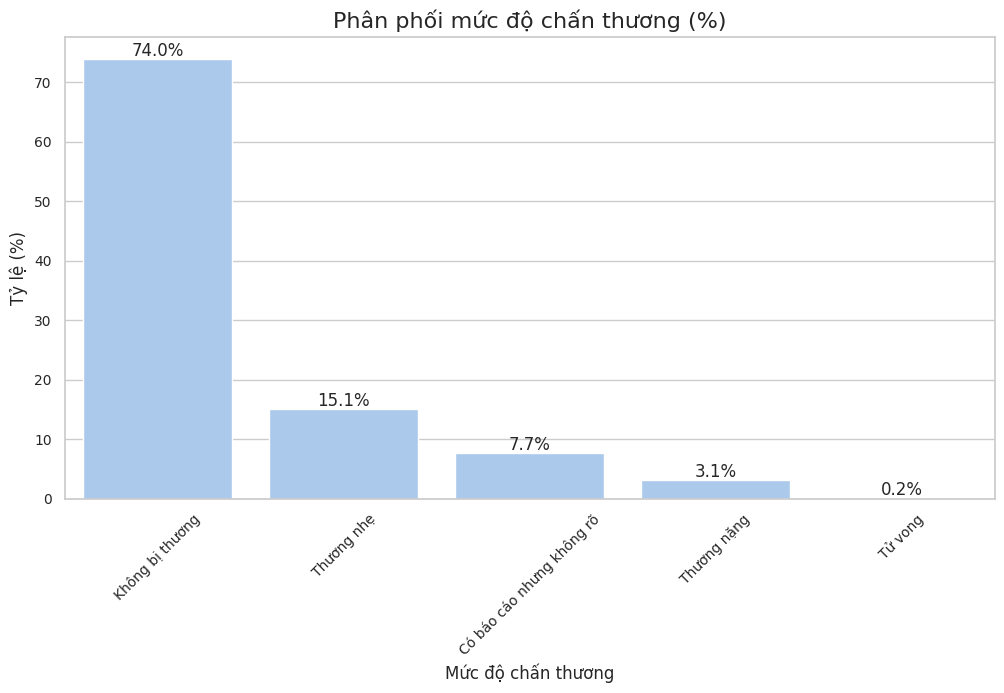

In [7]:
target_counts = df_vi['most_severe_injury'].value_counts()
target_pct = target_counts / target_counts.sum() * 100

plt.figure()
sns.barplot(x=target_counts.index, y=target_pct)

for i, v in enumerate(target_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.title("Phân phối mức độ chấn thương (%)")
plt.xticks(rotation=45)
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Tỷ lệ (%)")
plt.show()

1. Ảnh hưởng của thời gian

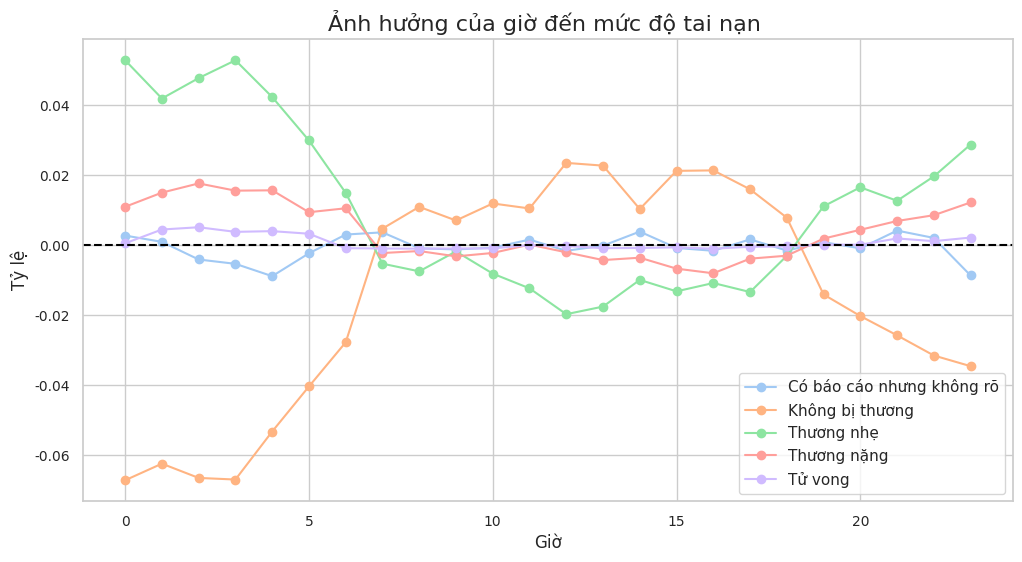

In [8]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)

temp = pd.crosstab(df_vi['crash_hour'], df_vi['most_severe_injury'], normalize='index')

impact = temp - baseline # tỷ lệ theo giờ - tỷ lệ trung bình của data

plt.figure()

for col in impact.columns:
    plt.plot(impact.index, impact[col], marker='o', label=col)

plt.axhline(0, linestyle='--', color='black')
plt.legend()
plt.title("Ảnh hưởng của giờ đến mức độ tai nạn ")
plt.xlabel("Giờ")
plt.ylabel("Tỷ lệ")
plt.show()

- Trong khung giờ 0–5h, tỷ lệ tai nạn không gây thương tích giảm mạnh so với trung bình, trong khi tỷ lệ tai nạn gây thương tích nhẹ tăng đáng kể. Điều này cho thấy các vụ tai nạn ban đêm ít khi “nhẹ hoàn toàn”, mà thường dẫn đến có thương tích.
- 6h -11h Buổi sáng (đặc biệt sau 7h) tai nạn có xu hướng ít nghiêm trọng hơn, dù tần suất có thể cao (giờ đi làm).
- 12h - 17h Khung giờ này là “an toàn tương đối” → Tai nạn chủ yếu không gây thương tích
- 18h -21h Đây là khung giờ chuyển pha nguy hiểm → Từ tai nạn nhẹ → bắt đầu có nhiều thương tích hơn (do tan tầm, đông xe, mệt mỏi)
- sau 21h Đêm muộn là khung giờ nguy hiểm cao → Tai nạn ít hơn nhưng nặng hơn


In [9]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    r, k = cm.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

print("Hour impact:", cramers_v(df_vi['crash_hour'], df_vi['most_severe_injury']))
print("Day impact:", cramers_v(df_vi['crash_day_of_week'], df_vi['most_severe_injury']))
print("Month impact:", cramers_v(df_vi['crash_month'], df_vi['most_severe_injury']))

Hour impact: 0.038034693772581805
Day impact: 0.015423186618197185
Month impact: 0.02206564179238037


Mặc dù biểu đồ cho thấy sự thay đổi mức độ chấn thương theo từng khung giờ, nhưng giá trị Cramér’s V rất thấp (≈0.038) cho thấy ảnh hưởng của thời gian là yếu, không mang tính quyết định.

Trong ba yếu tố thời gian, giờ xảy ra tai nạn có mức ảnh hưởng cao nhất, tuy nhiên vẫn ở mức rất thấp. Điều này cho thấy thời điểm trong ngày có tác động nhất định nhưng không đáng kể.

Giá trị thấp nhất (~0.015) cho thấy ngày trong tuần hầu như không liên quan đến mức độ nghiêm trọng của tai nạn.

2. Ảnh hưởng của ngày trong tuần

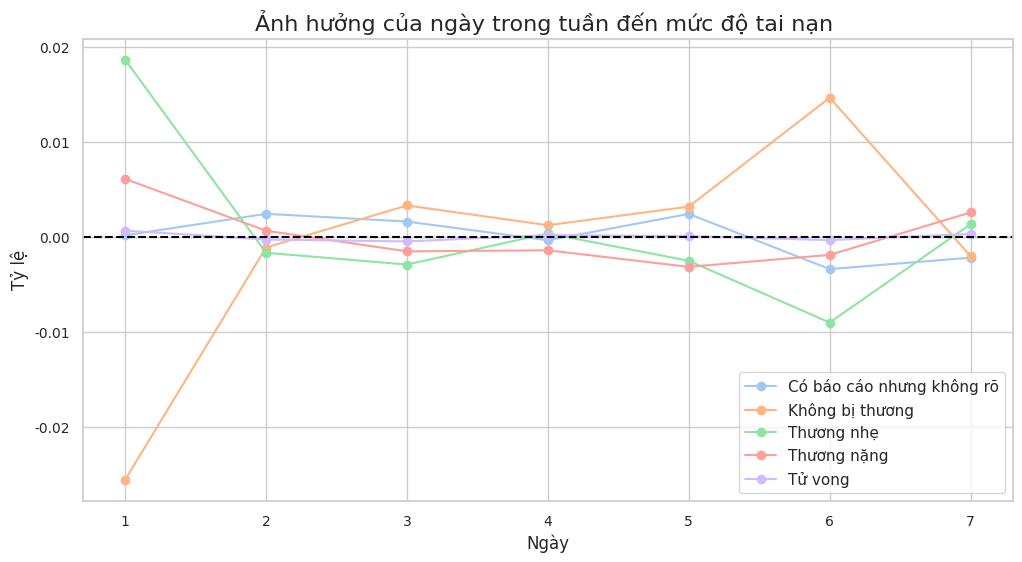

In [10]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)

temp = pd.crosstab(df_vi['crash_day_of_week'], df_vi['most_severe_injury'], normalize='index')

impact = temp - baseline # tỷ lệ theo giờ - tỷ lệ trung bình của data

plt.figure()

for col in impact.columns:
    plt.plot(impact.index, impact[col], marker='o', label=col)

plt.axhline(0, linestyle='--', color='black')
plt.legend()
plt.title("Ảnh hưởng của ngày trong tuần đến mức độ tai nạn ")
plt.xlabel("Ngày")
plt.ylabel("Tỷ lệ")
plt.show()

Phân bố mức độ chấn thương giữa các ngày trong tuần gần như tương đồng, không có sự khác biệt rõ rệt. Điều này cho thấy mức độ nghiêm trọng của tai nạn không phụ thuộc vào ngày trong tuần, mà có xu hướng ổn định xuyên suốt tuần.

3. Ảnh hưởng của tháng

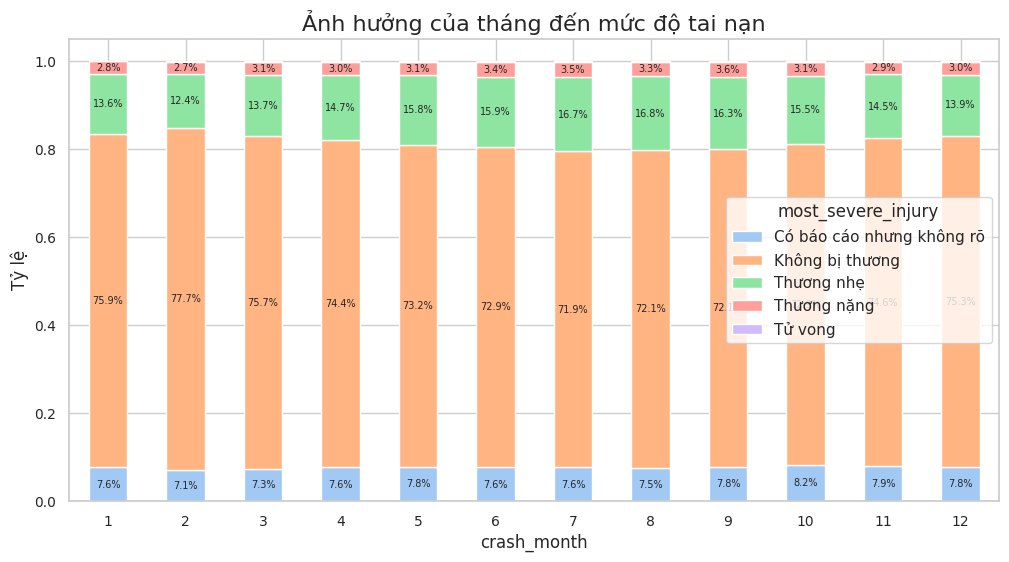

In [11]:
temp = pd.crosstab(df_vi['crash_month'], df_vi['most_severe_injury'], normalize='index')

ax = temp.plot(kind='bar', stacked=True)

plt.title("Ảnh hưởng của tháng đến mức độ tai nạn")
plt.xticks(rotation=0)
plt.ylabel("Tỷ lệ")

for i in range(len(temp)):  
    cum_height = 0
    for j, col in enumerate(temp.columns):
        val = temp.iloc[i, j]
        if val > 0.02:  
            ax.text(
                i,
                cum_height + val / 2,
                f"{val*100:.1f}%",
                ha='center',
                va='center',
                fontsize=7
            )
        cum_height += val

plt.show()

Phân bố mức độ chấn thương theo tháng cũng không có sự biến động đáng kể.Chỉ số Cramér’s V (~0.022) cho thấy ảnh hưởng của tháng đến mức độ chấn thương là rất yếu.

##### Ảnh hưởng của môi trường

4. Ảnh hưởng của thời tiết

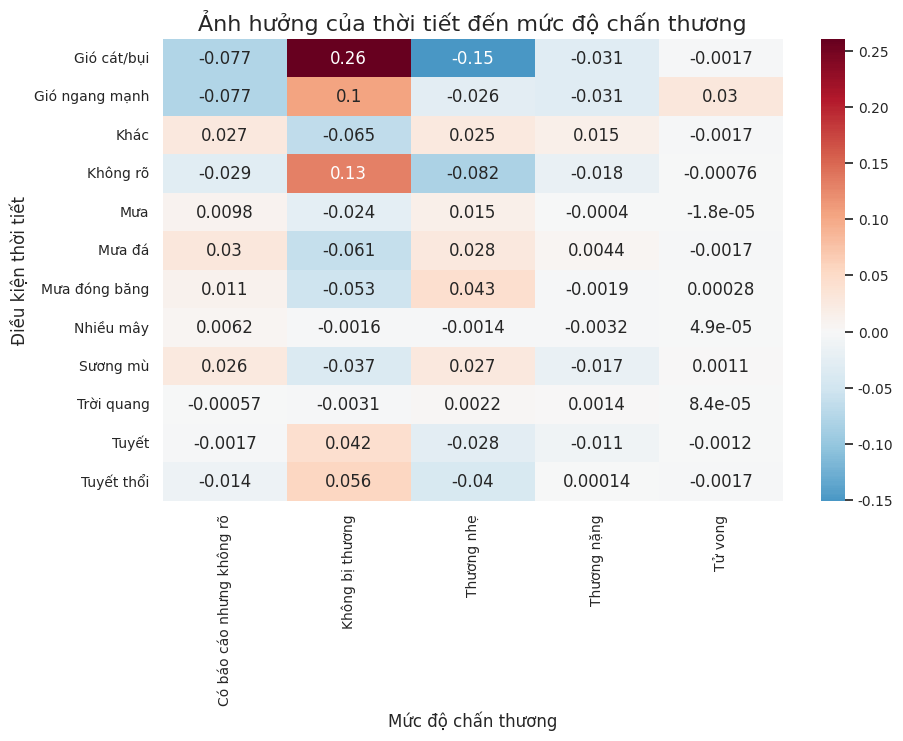

In [12]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
temp = pd.crosstab(df_vi['weather_condition'], df_vi['most_severe_injury'], normalize='index')

impact = temp - baseline

plt.figure(figsize=(10,6))
sns.heatmap(impact, annot=True, cmap="RdBu_r", center=0)

plt.title("Ảnh hưởng của thời tiết đến mức độ chấn thương")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Điều kiện thời tiết")
plt.show()

Thời tiết là yếu tố ảnh hưởng rõ rệt đến mức độ nghiêm trọng của tai nạn. Trong điều kiện thời tiết xấu, đặc biệt là mưa, tuyết và băng, nguy cơ xảy ra tai nạn có chấn thương (đặc biệt là thương nặng) tăng lên đáng kể. Điều này cho thấy việc kiểm soát phương tiện trở nên khó khăn hơn trong các điều kiện này, dẫn đến hậu quả nghiêm trọng hơn khi tai nạn xảy ra.

Mưa đóng băng và mưa đá là những điều kiện thời tiết khắc nghiệt nhất. Lớp băng mỏng trên đường khiến xe mất hoàn toàn độ bám. Tai nạn ở đây không chỉ là va chạm nhẹ mà thường là mất lái ở tốc độ cao, dẫn đến chấn thương nghiêm trọng.

Trời quang và nhiều mây: trong điều kiện thời tiết bình thường tai nạn chủ yếu không gây thương tích hoặc chỉ bị thương nhẹ

Sương mù và gió ngang mạnh có tỉ lệ tử vong cao do sương mù làm hạn chế tầm nhiều 

Thời tiết có ảnh hưởng rõ rệt đến mức độ nghiêm trọng của tai nạn. Khi điều kiện thời tiết xấu (mưa, sương mù, băng, mưa đá), tỷ lệ tai nạn không gây thương tích giảm, trong khi tỷ lệ thương nhẹ và thương nặng tăng lên đáng kể. Đặc biệt, các điều kiện mặt đường trơn trượt như mưa đóng băng và mưa đá làm gia tăng nguy cơ chấn thương nghiêm trọng.

5. Ảnh hưởng của điều kiện ánh sáng

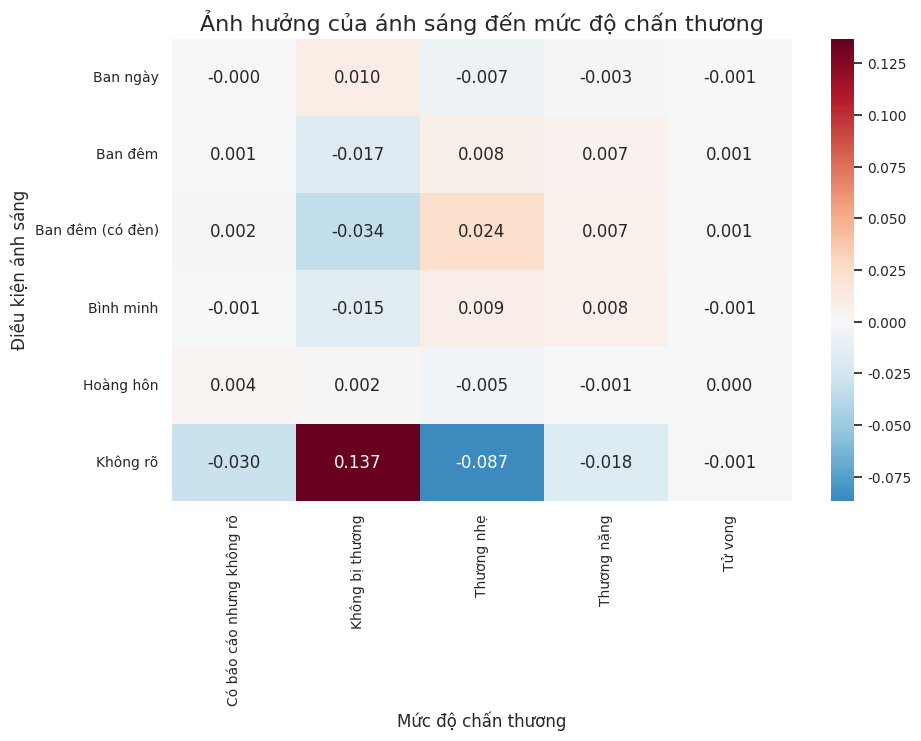

In [13]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)

temp = pd.crosstab(df_vi['lighting_condition'], df_vi['most_severe_injury'], normalize='index')
impact = temp - baseline

plt.figure(figsize=(10,6))
sns.heatmap(impact, annot=True, fmt=".3f", cmap="RdBu_r", center=0)

plt.title("Ảnh hưởng của ánh sáng đến mức độ chấn thương")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Điều kiện ánh sáng")
plt.show()

Ban đêm làm giảm khả năng tai nạn “không bị thương” và tăng tất cả các mức độ chấn thương.

Đèn đường không loại bỏ rủi ro,  múc độ bị thương nhẹ tăng 0.024

Ban ngày giúp giảm mức độ nghiêm trọng của tai nạn.

Điều kiện ánh sáng có ảnh hưởng đến mức độ nghiêm trọng của tai nạn, tuy nhiên mức độ tác động không quá lớn. Các điều kiện ánh sáng kém như ban đêm và bình minh làm gia tăng tỷ lệ tai nạn có chấn thương, trong khi ban ngày có xu hướng an toàn hơn. Đặc biệt, dù có đèn chiếu sáng, ban đêm vẫn ghi nhận mức tăng ở các trường hợp chấn thương, cho thấy ánh sáng nhân tạo chỉ giúp giảm nhẹ chứ không loại bỏ hoàn toàn rủi ro.

6. Ảnh hưởng của tình trạng mặt đường

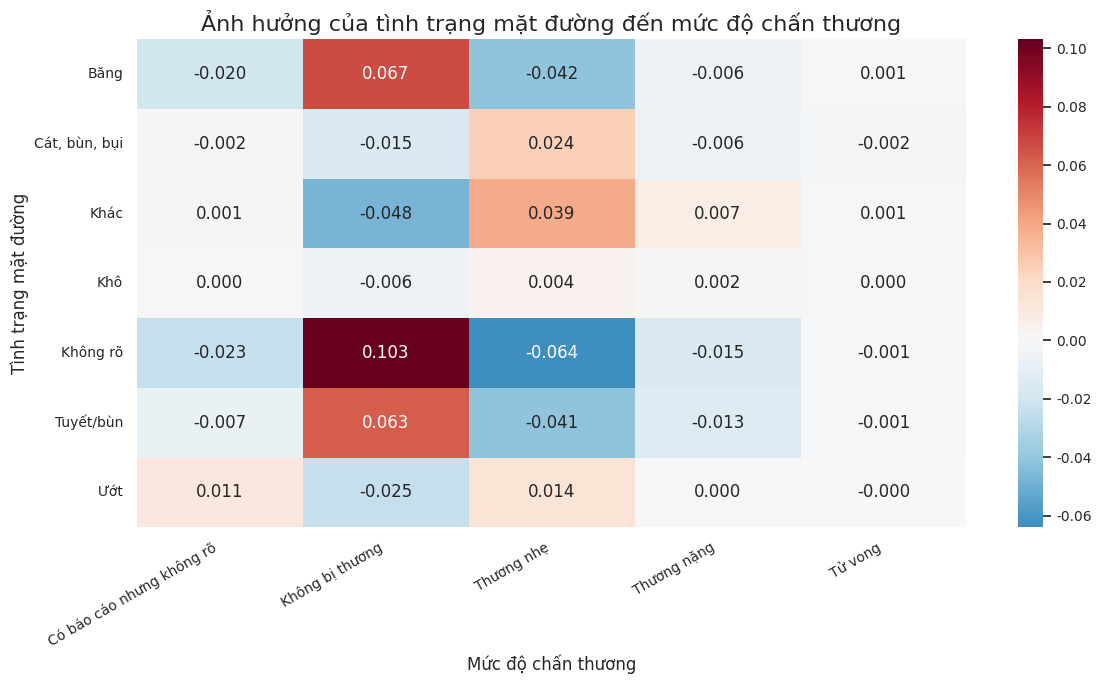

In [14]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
top = df_vi['roadway_surface_cond'].value_counts().head(10).index
temp = pd.crosstab(df_vi['roadway_surface_cond'], df_vi['most_severe_injury'], normalize='index')
impact = temp - baseline
plt.figure(figsize=(12,7))  
ax = sns.heatmap(impact, annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Ảnh hưởng của tình trạng mặt đường đến mức độ chấn thương")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Tình trạng mặt đường")
plt.yticks(rotation=0)             
plt.xticks(rotation=30, ha='right') 
plt.tight_layout()                
plt.show()

Khi tình trạng mặt đường được ghi nhận là “Không rõ”, rất nhiều vụ tai nạn chỉ ở mức không bị thương hoặc rất nhẹ. Điều này thường xảy ra ở các vụ va chạm nhỏ

Trên mặt đường băng, tài xế thường chạy rất chậm và cực kỳ cẩn thận. Do đó dù tai nạn xảy ra (do trượt bánh), tốc độ va chạm thấp -> hầu hết chỉ gây thiệt hại vật chất, ít gây chấn thương nghiêm trọng.


##### Ảnh hưởng của giao thông

7. Ảnh hưởng của thiết bị điều khiển giao thông

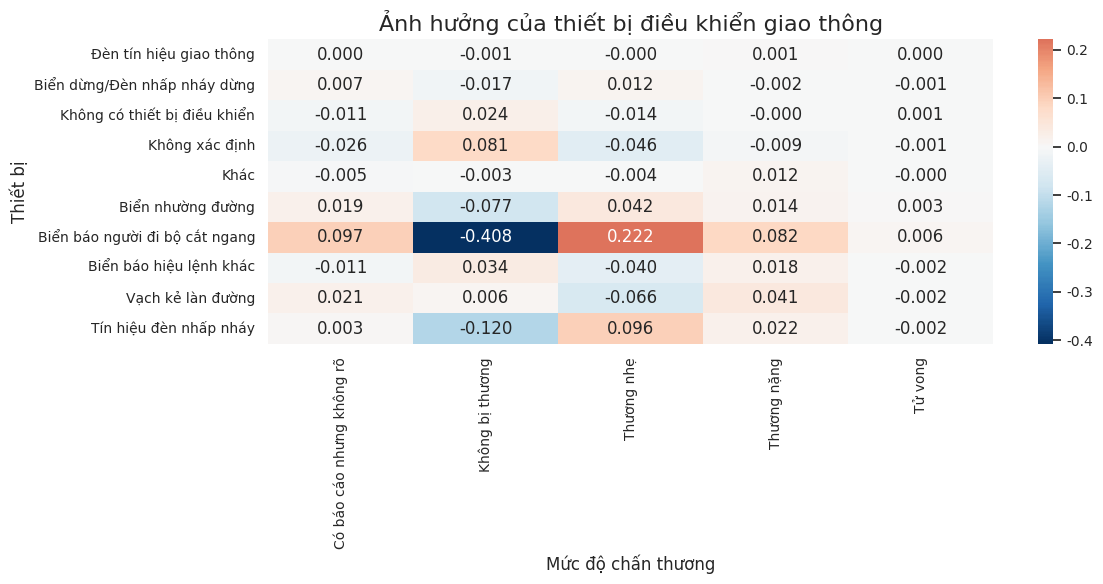

In [15]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
top = df_vi['traffic_control_device'].value_counts().head(10).index
temp = pd.crosstab(df_vi['traffic_control_device'], df_vi['most_severe_injury'], normalize='index')
impact = temp - baseline

plt.figure(figsize=(12,6))
sns.heatmap( impact.loc[top], annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Ảnh hưởng của thiết bị điều khiển giao thông")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Thiết bị")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

“Biển báo người đi bộ cắt ngang” là nhóm bất thường và nguy hiểm nhất
- Không bị thương: -0.408 giảm mạnh
- Bị thương nhẹ 0.222 tăng rất mạnh
- Bị thương nặng tăng 0.082
- Tỉ lệ tử vong tăng nhẹ

Đây là nhóm rủi ro chấn thương cao nhất trong tất cả thiết bị giao thông. Vì va chạm trực tiếp với người đi bộ làm tăng tỉ lệ các chấn thương

Đèn nhấp nháy (thường dùng ở khu vực nguy hiểm, trường học, công trường…) làm giảm mạnh tỷ lệ “không bị thương” và tăng tỷ lệ có thương tích nhẹ. Tài xế có thể chủ quan hoặc tốc độ vẫn còn cao dù có đèn cảnh báo.

Tại biển nhường đường, tai nạn cũng có xu hướng gây thương tích nhiều hơn so với trung bình, dù mức độ không mạnh bằng biển người đi bộ.

Khi không có bất kỳ thiết bị điều khiển nào, tai nạn có xu hướng nhẹ hơn (nhiều vụ chỉ va chạm vật chất, không gây chấn thương). Có thể do tốc độ thấp hơn ở những khu vực ít kiểm soát (hẻm, đường phụ, bãi đỗ…).

8. Ảnh hưởng của loại đường

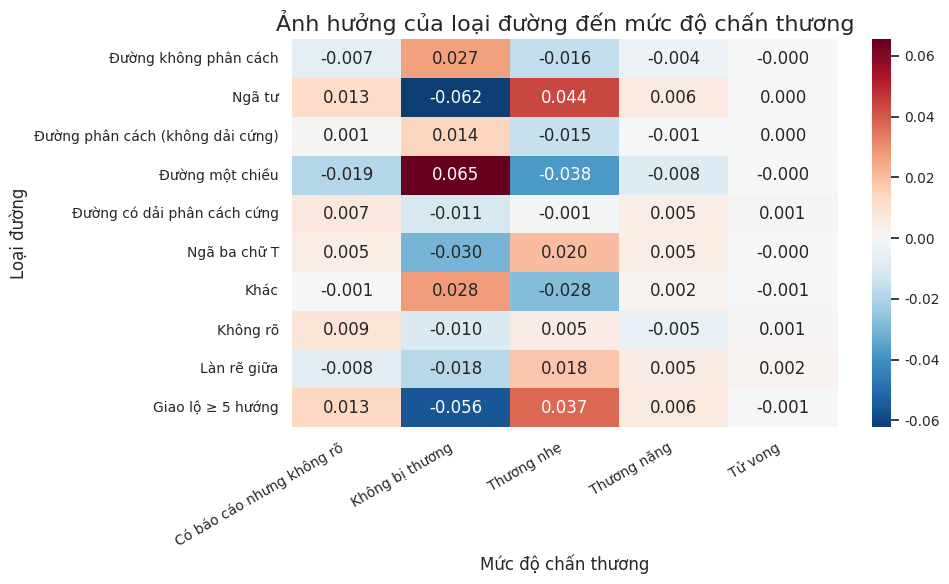

In [16]:
top = df_vi['trafficway_type'].value_counts().head(10).index
temp = pd.crosstab( df_vi['trafficway_type'], df_vi['most_severe_injury'], normalize='index')
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
impact = temp - baseline
# chỉ lấy top 10 loại đường
impact_top = impact.loc[top]
plt.figure(figsize=(10,6))
sns.heatmap(impact_top, annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title("Ảnh hưởng của loại đường đến mức độ chấn thương")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Loại đường")
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Ngã tư (FOUR WAY) và Giao lộ 5 hướng là hai loại đường nguy hiểm nhất

Ngã tư:
- Không bị thương: -0.062 giảm mạnh
- Thương nhẹ: +0.044 tăng rõ
- Thương nặng: +0.006

Giao lộ ≥ 5 hướng:
- Không bị thương: -0.056 (giảm mạnh)
- Thương nhẹ: +0.037 (tăng)
- Thương nặng: +0.006

Trên đường một chiều, tai nạn thường nhẹ hơn rất nhiều. Nguyên nhân chính:
- không có va chạm ngược chiều (head-on hoặc sideswipe opposite).
- Tất cả xe di chuyển cùng hướng → va chạm chủ yếu là quệt cùng chiều hoặc va phía sau ở tốc độ tương đối.
- Tài xế dễ dự đoán hướng di chuyển của xe khác.

Trong các loại đường, ngã tư và giao lộ nhiều hướng là những nơi có mức độ chấn thương cao hơn trung bình, với tỷ lệ thương nhẹ tăng đáng kể (+0.037 đến +0.044). Ngược lại, đường một chiều là loại đường an toàn nhất về mặt chấn thương, làm giảm mạnh tỷ lệ có thương tích.

9. Ảnh hưởng của giao lộ

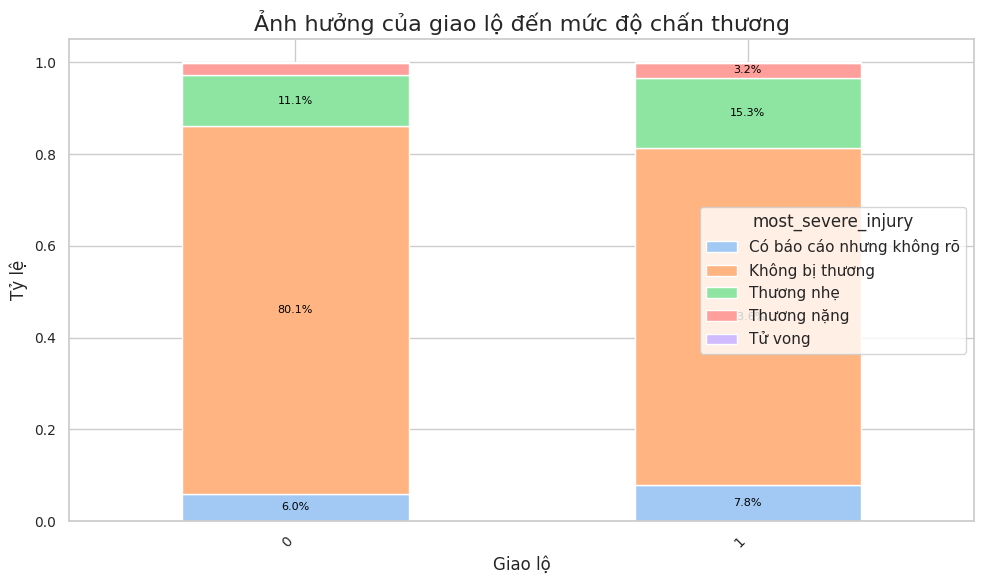

In [17]:
temp = pd.crosstab(df_vi['intersection_related_i'], df_vi['most_severe_injury'], normalize='index')
ax = temp.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Ảnh hưởng của giao lộ đến mức độ chấn thương")
plt.ylabel("Tỷ lệ")
plt.xlabel("Giao lộ")
plt.xticks(rotation=45, ha='right')
for i, (idx, row) in enumerate(temp.iterrows()):
    cum = 0
    for val in row:
        if val > 0.03: 
            ax.text(
                i,
                cum + val/2,
                f"{val*100:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )
        cum += val
plt.tight_layout()
plt.show()

Tai nạn tại giao lộ có mức độ nghiêm trọng cao hơn đáng kể so với tai nạn không liên quan đến giao lộ. Cụ thể, tỷ lệ thương nhẹ tăng thêm 4.2% và tỷ lệ thương nặng cũng cao hơn. Điều này cho thấy giao lộ là một trong những yếu tố môi trường có ảnh hưởng rõ nét đến mức độ chấn thương. Việc tập trung cải thiện hạ tầng và kiểm soát giao thông tại các giao lộ sẽ mang lại hiệu quả cao trong việc giảm chấn thương nghiêm trọng.

10. Ảnh hưởng của loại tai nạn

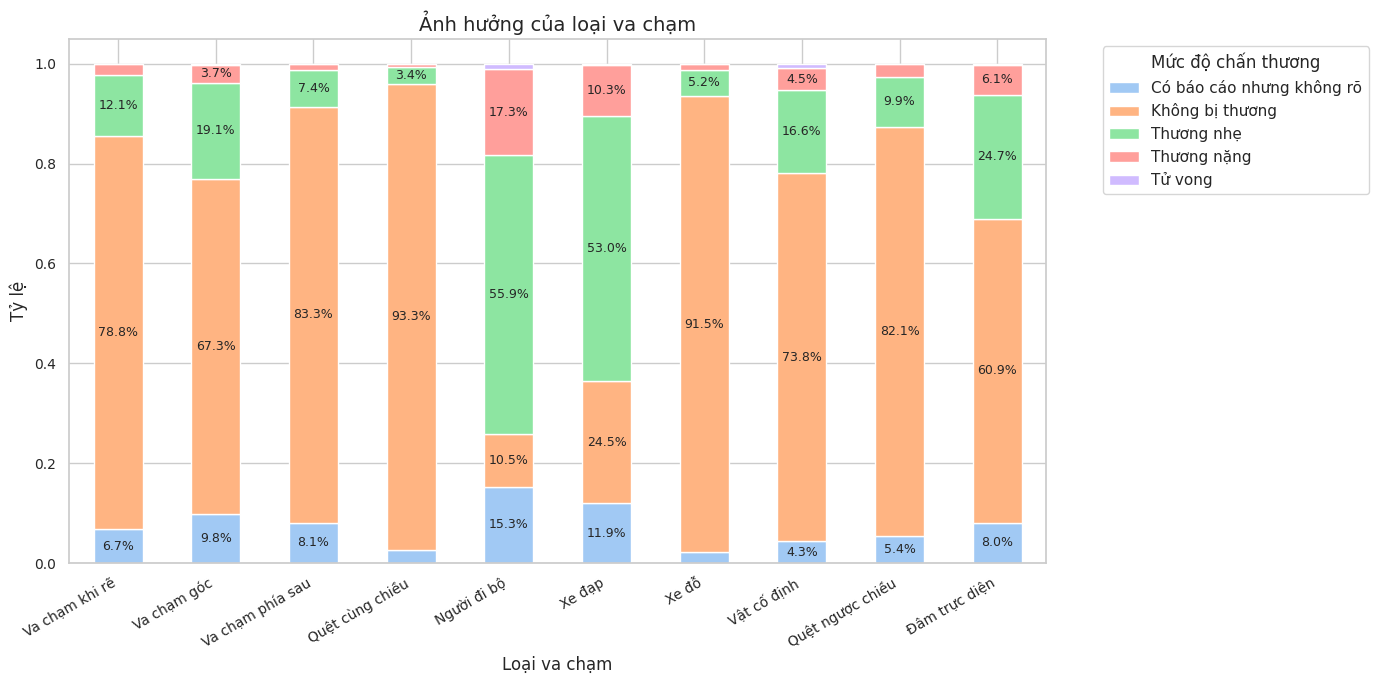

In [18]:
top_crash = df_vi['first_crash_type'].value_counts().head(10).index
temp = pd.crosstab(df_vi['first_crash_type'], df_vi['most_severe_injury'], normalize='index')
data = temp.loc[top_crash]
fig, ax = plt.subplots(figsize=(14,7))
data.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for i, (idx, row) in enumerate(data.iterrows()):
    cumulative = 0
    for val in row:
        if val > 0.03:  
            ax.text(
                i,
                cumulative + val/2,
                f"{val*100:.1f}%",
                ha='center',
                va='center',
                fontsize=9
            )
        cumulative += val
plt.title("Ảnh hưởng của loại va chạm", fontsize=14)
plt.xlabel("Loại va chạm")
plt.ylabel("Tỷ lệ")
plt.legend(title="Mức độ chấn thương", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

Hai loại va chạm nguy hiểm nhất về chấn thương:

Người đi bộ (PEDESTRIAN):
- Không bị thương: chỉ 10.5% (rất thấp).
- Thương nhẹ: 55.9% (cao nhất trong tất cả loại).
- Thương nặng: 17.3%.
- Tử vong: gần 1% (cao nhất nhóm).
- Có báo cáo nhưng không rõ: 15.3%.

Va chạm với người đi bộ là loại nguy hiểm nhất về chấn thương. Hơn 73% các vụ đều gây thương tích (nhẹ + nặng), trong đó tỷ lệ thương nhẹ và thương nặng rất cao.

Đâm trực diện:
- Không bị thương: 60.9% (thấp nhất trong các loại va chạm cơ giới).
- Thương nhẹ: 24.7%.
- Thương nặng: 6.1%.
- Tử vong:0.3 (cao hơn trung bình)

Va chạm trực diện thường xảy ra với tốc độ cao -> mức độ chấn thương nghiêm trọng hơn hẳn so với các loại va chạm khác

Các loại va chạm tương đối an toàn:
- Quệt cùng chiều: 93.3% Không bị thương -> an toàn nhất.
- Va chạm phía sau: 83.3% Không bị thương.
- Xe đỗ: 91.5% Không bị thương.
- Va chạm khi rẽ: 78.8% Không bị thương.

Những loại này thường xảy ra ở tốc độ thấp hoặc cùng hướng -> ít gây chấn thương cho con người.

Nhóm trung bình – vẫn có tỷ lệ chấn thương đáng kể:
- Va chạm góc: 19.1% thương nhẹ + 3.7% thương nặng.
- Xe đạp: 53.0% thương nhẹ + 10.3% thương nặng -> rất nguy hiểm cho người đi xe đạp.
- Vật cố định: 16.6% thương nhẹ + 4.5% thương nặng.
- Quệt ngược chiều: 9.9% thương nhẹ.


11. Ảnh hưởng của nguyên nhân

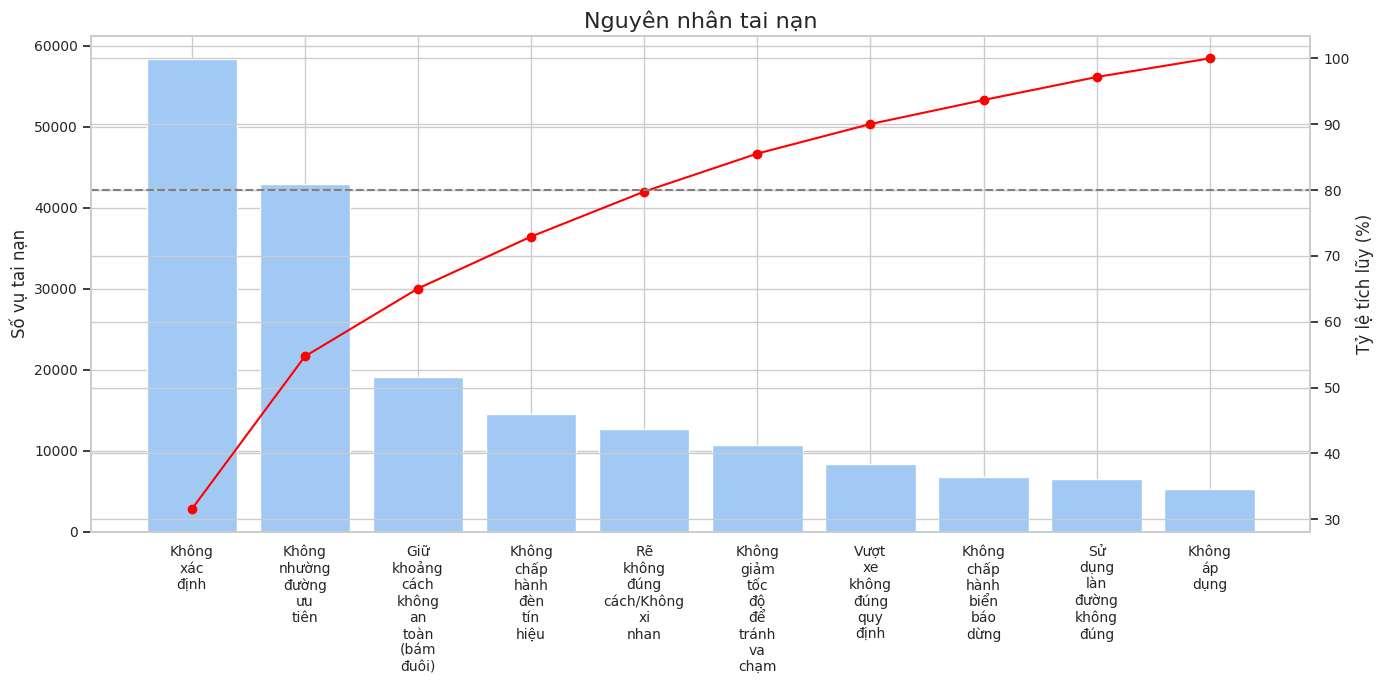

In [19]:
cause_counts = df_vi['prim_contributory_cause'].value_counts().head(10)
cum_pct = cause_counts.cumsum() / cause_counts.sum() * 100
fig, ax1 = plt.subplots(figsize=(14,7))
ax1.bar(range(len(cause_counts)), cause_counts)
ax1.set_ylabel("Số vụ tai nạn")
ax2 = ax1.twinx()
ax2.plot(range(len(cause_counts)), cum_pct, color='red', marker='o')
ax2.set_ylabel("Tỷ lệ tích lũy (%)")
labels = [label.replace(" ", "\n") for label in cause_counts.index]
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=0, ha='center')
ax2.axhline(80, color='gray', linestyle='--')
plt.title("Nguyên nhân tai nạn")
plt.tight_layout()
plt.show()

Biểu đồ Pareto cho thấy nguyên nhân tai nạn rất tập trung:
- 2 nguyên nhân đầu tiên đã chiếm gần 55% tổng số vụ
- 5 nguyên nhân đầu tiên chiếm khoảng 80%
- Phần còn lại là các nguyên nhân nhỏ lẻ

Hành vi của con người là nguyên nhân chính của hầu hết tai nạn nếu loại bỏ nhóm "Không xác định"

Không nhường đường ->  giải thích tại sao giao lộ, ngã tư, biển người đi bộ, và va chạm góc lại có mức độ chấn thương cao.

Bám đuôi + không giảm tốc độ -> giải thích tại sao va chạm phía sau lại nhiều nhưng ít gây chấn thương nghiêm trọng (tốc độ tương đối thấp).

Không chấp hành đèn tín hiệu -> làm tăng nguy cơ tại ngã tư và va chạm góc.

Đâm trực diện và va chạm với người đi bộ thường liên quan đến lỗi tốc độ + không nhường đường + không quan sát.

#### Phân tích kết hợp nhiều yếu tố

##### Thời tiết  và ánh sáng

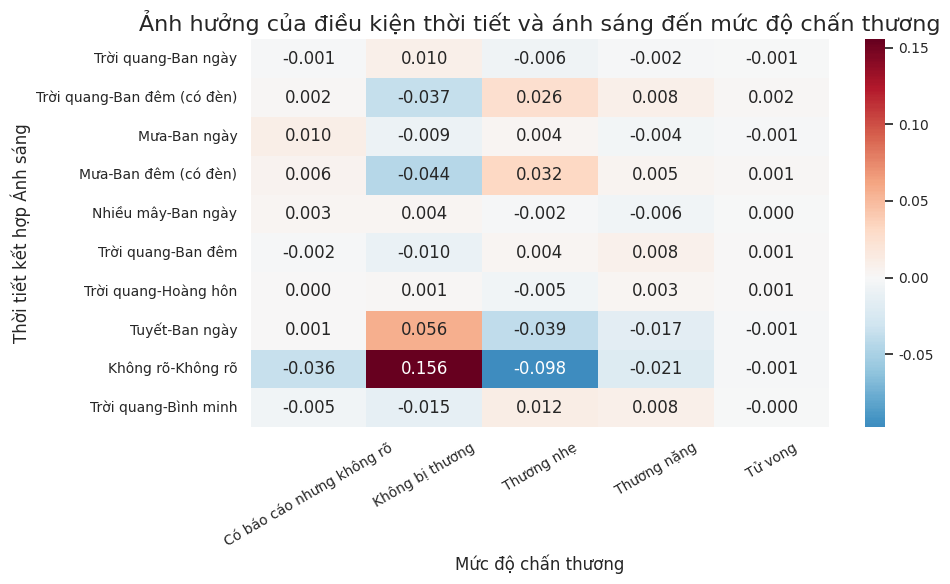

In [20]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
cross = pd.crosstab(
    [df_vi['weather_condition'], df_vi['lighting_condition']],
    df_vi['most_severe_injury'],
    normalize='index'
)
impact = cross - baseline
count = pd.crosstab(
    [df_vi['weather_condition'], df_vi['lighting_condition']],
    df_vi['most_severe_injury']
).sum(axis=1)
impact['count'] = count
# chọn top 10 combo phổ biến nhất
top = impact.sort_values('count', ascending=False).head(10).index
impact_top = impact.loc[top].drop(columns='count')
plt.figure(figsize=(10,6))
sns.heatmap(impact_top, annot=True, cmap="RdBu_r", center=0, fmt=".3f")
plt.title("Ảnh hưởng của điều kiện thời tiết và ánh sáng đến mức độ chấn thương")
plt.xlabel("Mức độ chấn thương")
plt.ylabel("Thời tiết kết hợp Ánh sáng")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Mưa + Ban đêm (có đèn) là tổ hợp nguy hiểm nhất trong các điều kiện thực tế
- Không bị thương: -0.044 (giảm rõ)
- Thương nhẹ: +0.032 (tăng rõ)
- Thương nặng: +0.005 (tăng nhẹ)
- Tử vong: +0.001

Trời quang + Ban đêm (có đèn)
- Không bị thương: -0.037 (giảm)
- Thương nhẹ: +0.026 (tăng)
- Thương nặng: +0.008 (tăng)

Tuyết + Ban ngày
- Không bị thương: +0.056 (tăng rõ).
- Thương nhẹ: -0.039 (giảm rõ).
- Thương nặng: -0.017.

Các tổ hợp ban ngày (Trời quang-Ban ngày, Nhiều mây-Ban ngày, Mưa-Ban ngày) ảnh hưởng rất nhỏ, gần với baseline -> ban ngày là điều kiện an toàn nhất, ít bị ảnh hưởng bởi thời tiết.

Tương tác giữa thời tiết và ánh sáng cho thấy mưa kết hợp với ban đêm là điều kiện nguy hiểm nhất, làm giảm tỷ lệ tai nạn không gây thương tích và tăng tỷ lệ thương nhẹ (+0.032) cũng như thương nặng. Ngay cả khi trời quang, ban đêm vẫn làm tăng nguy cơ chấn thương so với ban ngày.

Ngược lại, tuyết rơi vào ban ngày lại khiến tai nạn trở nên nhẹ hơn nhờ hành vi điều chỉnh của tài xế.

##### Tình trạng mặt đường và thời tiết

<Axes: xlabel='most_severe_injury', ylabel='weather_condition-roadway_surface_cond'>

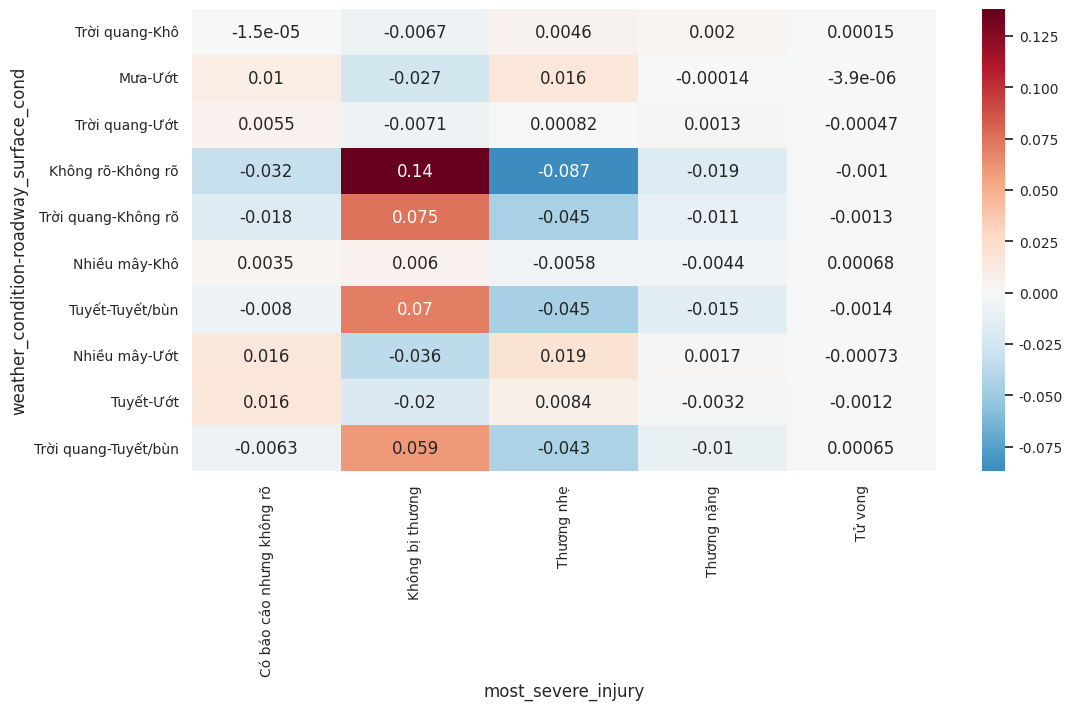

In [21]:
baseline = df_vi['most_severe_injury'].value_counts(normalize=True)
cross = pd.crosstab(
    [df_vi['weather_condition'], df_vi['roadway_surface_cond']],
    df_vi['most_severe_injury'],
    normalize='index'
)
impact = cross - baseline
cross['count'] = pd.crosstab(
    [df_vi['weather_condition'], df_vi['roadway_surface_cond']],
    df_vi['most_severe_injury']
).sum(axis=1)
top = cross.sort_values('count', ascending=False).head(10).index
impact_top = impact.loc[top]
sns.heatmap(impact_top, annot=True, cmap="RdBu_r", center=0)

Tương tác giữa thời tiết và tình trạng mặt đường cho thấy mưa kết hợp với mặt đường ướt là tổ hợp làm tăng rõ rệt tỷ lệ thương nhẹ (+0.016) và giảm tỷ lệ không bị thương. Ngược lại, các điều kiện tuyết/tuyết-bùn (kể cả trời quang) lại khiến tai nạn trở nên nhẹ hơn đáng kể nhờ tài xế chủ động giảm tốc độ và tăng khoảng cách an toàn. Kết quả nhấn mạnh rằng rủi ro chấn thương không chỉ đến từ mặt đường trơn trượt, mà chủ yếu từ sự kết hợp đột ngột giữa thời tiết xấu và mặt đường ẩm ướt.